In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

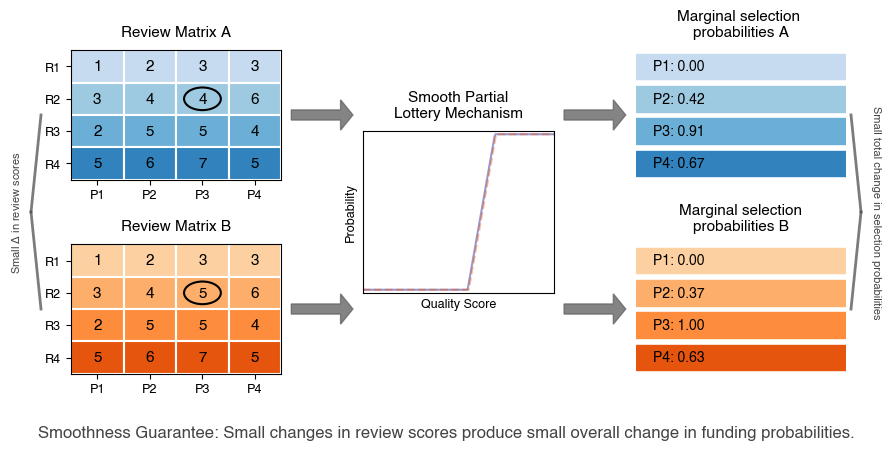

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# ------------------------------------------------
# Smooth clipped mechanism
# ------------------------------------------------
def smooth_probs_from_reviews(R, k, score_max=None, tol=1e-8, max_iter=200):
    mean_scores = R.mean(axis=0)
    if score_max is None:
        score_max = np.max(R)

    lo, hi = -score_max, score_max
    for _ in range(max_iter):
        tau = 0.5 * (lo + hi)
        p = np.clip(mean_scores - tau, 0, 1)
        total = p.sum()
        if abs(total - k) < tol:
            return p, tau, mean_scores
        if total > k:
            lo = tau
        else:
            hi = tau
    return np.clip(mean_scores - tau, 0, 1), tau, mean_scores

def round_probabilities_to_sum(probs, target_sum, decimals=2):
    """
    Round probabilities to specified decimals while ensuring they sum to target_sum.
    Uses controlled adjustment method.
    """
    # Round each probability
    rounded = np.round(probs, decimals)
    current_sum = np.round(rounded.sum(), decimals)
    
    # Calculate the discrepancy
    discrepancy = np.round(target_sum - current_sum, decimals)
    
    if abs(discrepancy) < 10**(-decimals):
        return rounded
    
    # We need to adjust by adding/subtracting 0.01 to certain elements
    adjustment = 0.01 if discrepancy > 0 else -0.01
    n_adjustments = int(round(abs(discrepancy) / 0.01))
    
    # Calculate how much each element was rounded (to determine which to adjust)
    rounding_errors = probs - rounded
    
    # If we need to add, adjust elements that were rounded down the most
    # If we need to subtract, adjust elements that were rounded up the most
    if discrepancy > 0:
        indices = np.argsort(rounding_errors)[-n_adjustments:]
    else:
        indices = np.argsort(rounding_errors)[:n_adjustments]
    
    adjusted = rounded.copy()
    adjusted[indices] += adjustment
    
    return np.round(adjusted, decimals)

# ------------------------------------------------
# Review matrices A and B
# ------------------------------------------------
A = np.array([
    [1, 2, 3, 3],
    [3, 4, 4, 6],
    [2, 5, 5, 4],
    [5, 6, 7, 5],
], dtype=float)

B = A.copy()
B[1, 2] += 1   # small change in one entry

k = 2
score_max = 7

pA, tauA, meanA = smooth_probs_from_reviews(A, k, score_max)
pB, tauB, meanB = smooth_probs_from_reviews(B, k, score_max)

# Round probabilities so they sum to exactly k when displayed
pA_display = round_probabilities_to_sum(pA, k, decimals=2)
pB_display = round_probabilities_to_sum(pB, k, decimals=2)

# Row-based colors
row_colors_A = ["#c6dbef", "#9ecae1", "#6baed6", "#3182bd"]  # blues
row_colors_B = ["#fdd0a2", "#fdae6b", "#fd8d3c", "#e6550d"]  # oranges

def draw_review_matrix(ax, R, row_colors, title):
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_xticks(range(R.shape[1]))
    ax.set_yticks(range(R.shape[0]))
    ax.set_xticklabels([f"P{i+1}" for i in range(R.shape[1])], fontsize=9)
    ax.set_yticklabels([f"R{i+1}" for i in range(R.shape[0])], fontsize=9)
    ax.set_xlim(-0.5, R.shape[1] - 0.5)
    ax.set_ylim(R.shape[0] - 0.5, -0.5)
    for i in range(R.shape[0]):
        for j in range(R.shape[1]):
            ax.add_patch(plt.Rectangle(
                (j - 0.5, i - 0.5), 1, 1,
                color=row_colors[i], ec="white", linewidth=1.5
            ))
            ax.text(j, i, f"{int(R[i,j])}", ha="center", va="center", 
                   color="black", fontsize=11, fontweight='500')

# ------------------------------------------------
# Build figure with smaller middle plot
# ------------------------------------------------
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'normal'
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 9

fig = plt.figure(figsize=(10, 4.2))
gs = gridspec.GridSpec(
    2, 3,
    width_ratios=[1.1, 1.0, 1.1],  # middle is wider
    height_ratios=[1, 1],
    wspace=0.4, hspace=0.5  # reduced whitespace
)

# Create a sub-gridspec for the middle column to make it shorter
gs_middle = gridspec.GridSpecFromSubplotSpec(
    3, 1, subplot_spec=gs[:, 1], 
    height_ratios=[0.5, 1, 0.5],  # more padding = shorter plot
    hspace=0
)

# Left: Matrix A
axA = fig.add_subplot(gs[0, 0])
draw_review_matrix(axA, A, row_colors_A, "Review Matrix A")
circA = plt.Circle((2, 1), 0.35, fill=False, edgecolor="black", linewidth=1.5)
axA.add_patch(circA)

# Left: Matrix B
axB = fig.add_subplot(gs[1, 0])
draw_review_matrix(axB, B, row_colors_B, "Review Matrix B")
circB = plt.Circle((2, 1), 0.35, fill=False, edgecolor="black", linewidth=1.5)
axB.add_patch(circB)

# Middle: Smooth lottery mapping with TWO lines (one for each tau) - using sub-gridspec
axM = fig.add_subplot(gs_middle[1, 0])
scores_grid = np.linspace(0, score_max, 200)

# Blue line for lottery A (solid, more transparent)
probs_grid_A = np.clip(scores_grid - tauA, 0, 1)
axM.plot(scores_grid, probs_grid_A, linewidth=1.5, color="darkblue", 
         linestyle='-', alpha=0.4, label="Lottery A")

# Orange line for lottery B (dashed)
probs_grid_B = np.clip(scores_grid - tauB, 0, 1)
axM.plot(scores_grid, probs_grid_B, linewidth=1.5, color="#e6550d", 
         linestyle='--', alpha=0.4, label="Lottery B")

axM.set_xlim(0, score_max)
axM.set_ylim(-0.02, 1.02)
axM.set_xlabel("Quality Score", fontsize=9, fontweight='normal')
axM.set_ylabel("Probability", fontsize=9, fontweight='normal')
axM.set_title("Smooth Partial\nLottery Mechanism", fontsize=11, fontweight='bold', pad=10)
axM.set_xticks([])
axM.set_yticks([])
axM.grid(False)

# Right top: Output marginals for A, color-coded to match rows
axPA = fig.add_subplot(gs[0, 2])
axPA.set_title("Marginal selection \nprobabilities A", fontsize=11, fontweight='bold', pad=10)
axPA.axis("off")
for i, p in enumerate(pA_display):
    axPA.add_patch(plt.Rectangle((0, 3 - i - 0.4), 1.2, 0.8,
                                 color=row_colors_A[i]))
    axPA.text(0.1, 3 - i, f"P{i+1}: {p:.2f}",
              ha="left", va="center", color="black", fontsize=10, fontweight='500')
axPA.set_xlim(0, 1.2)
axPA.set_ylim(-0.5, 3.5)

# Right bottom: Output marginals for B, color-coded to match rows
axPB = fig.add_subplot(gs[1, 2])
axPB.set_title("Marginal selection\nprobabilities B", fontsize=11, fontweight='bold', pad=10)
axPB.axis("off")
for i, p in enumerate(pB_display):
    axPB.add_patch(plt.Rectangle((0, 3 - i - 0.4), 1.2, 0.8,
                                 color=row_colors_B[i]))
    axPB.text(0.1, 3 - i, f"P{i+1}: {p:.2f}",
              ha="left", va="center", color="black", fontsize=10, fontweight='500')
axPB.set_xlim(0, 1.2)
axPB.set_ylim(-0.5, 3.5)

# Get the actual positions of the subplots in figure coordinates
pos_A = axA.get_position()  # Matrix A
pos_B = axB.get_position()  # Matrix B
pos_M = axM.get_position()  # Middle mechanism
pos_PA = axPA.get_position()  # Output A
pos_PB = axPB.get_position()  # Output B

# Add arrows from inputs to mechanism (horizontal only)
arrow_A = plt.Arrow(
    pos_A.x1 + 0.01,
    (pos_A.y0 + pos_A.y1) / 2,
    pos_M.x0 - pos_A.x1 - 0.02,
    0,
    width=0.12, color="#666666", alpha=0.8
)
fig.add_artist(arrow_A)

arrow_B = plt.Arrow(
    pos_B.x1 + 0.01,
    (pos_B.y0 + pos_B.y1) / 2,
    pos_M.x0 - pos_B.x1 - 0.02,
    0,
    width=0.12, color="#666666", alpha=0.8
)
fig.add_artist(arrow_B)

# Add arrows from mechanism to outputs (horizontal only)
arrow_out_A = plt.Arrow(
    pos_M.x1 + 0.01,
    (pos_A.y0 + pos_A.y1) / 2,
    pos_PA.x0 - pos_M.x1 - 0.02,
    0,
    width=0.12, color="#666666", alpha=0.8
)
fig.add_artist(arrow_out_A)

arrow_out_B = plt.Arrow(
    pos_M.x1 + 0.01,
    (pos_B.y0 + pos_B.y1) / 2,
    pos_PB.x0 - pos_M.x1 - 0.02,
    0,
    width=0.12, color="#666666", alpha=0.8
)
fig.add_artist(arrow_out_B)

# Add bracket on the left between matrices with annotation
left_x = pos_A.x0 - 0.04
top_y = (pos_A.y0 + pos_A.y1) / 2
bottom_y = (pos_B.y0 + pos_B.y1) / 2
mid_y = (top_y + bottom_y) / 2

fig.add_artist(plt.Line2D([left_x + 0.01, left_x], [top_y, mid_y], 
                          color='#444444', linewidth=2, alpha=0.7))
fig.add_artist(plt.Line2D([left_x + 0.01, left_x], [bottom_y, mid_y], 
                          color='#444444', linewidth=2, alpha=0.7))

fig.text(left_x - 0.015, mid_y, r'Small $\Delta$ in review scores', 
         ha='center', va='center', fontsize=8, color='#444444', 
         style='italic', rotation=90)

# Add bracket on the right between outputs with annotation
right_x = pos_PA.x1 + 0.015
top_y_out = (pos_PA.y0 + pos_PA.y1) / 2
bottom_y_out = (pos_PB.y0 + pos_PB.y1) / 2
mid_y_out = (top_y_out + bottom_y_out) / 2

fig.add_artist(plt.Line2D([right_x - 0.01, right_x], [top_y_out, mid_y_out], 
                          color='#444444', linewidth=2, alpha=0.7))
fig.add_artist(plt.Line2D([right_x - 0.01, right_x], [bottom_y_out, mid_y_out], 
                          color='#444444', linewidth=2, alpha=0.7))

fig.text(right_x + 0.015, mid_y_out, 'Small total change in selection probabilities', 
         ha='center', va='center', fontsize=8, color='#444444', 
         style='italic', rotation=270)

fig.text(
    0.5, -0.03,
    "Smoothness Guarantee: Small changes in review scores produce small overall change "
    "in funding probabilities.",
    ha="center", va="center", fontsize=12, style='italic', color='#444444'
)

plt.show()